In [1]:
!pwd

/home/alan_khang/dev/mirror3d


In [2]:
from model import M3DWrapper

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import shutil

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
cfg_file = './mirror3d/mirror3dnet/config/mirror3dnet_config.yml'
anchor_normal_npy = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation/kmeans_normal_10.npy'
m3d_weight_path = './output/mirror_glass_segm_v11/m3n_full_rawD_resume_2026-03-30-21-24-40/model_0005999.pth'
focal_length = 524  
input_width = 640
input_height = 360
score_threshold = 0.8

m3d_model = M3DWrapper(
    cfg_file=cfg_file,
    anchor_normal_npy=anchor_normal_npy,
    m3d_weight_path=m3d_weight_path,
    focal_length=focal_length,
    input_width=input_width,
    input_height=input_height,
    score_threshold=score_threshold)

/home/alan_khang/miniconda3/envs/mirror3d/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [7]:
ori_img_1 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/color/oak_right_frame_0000210.jpg')
ori_depth_1 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/depth/oak_right_frame_0000210.png', cv2.IMREAD_ANYDEPTH)

batch_output = m3d_model.run([ori_img_1], [ori_depth_1])

In [8]:
ref_depth = batch_output[0]['refined_depth']
pred_masks = batch_output[0]['pred_masks']
pred_bboxes = batch_output[0]['pred_bboxes']
pred_classes = batch_output[0]['pred_cls']
pred_scores = batch_output[0]['pred_scores']

drawed_img = ori_img_1.copy()
for mask, bbox, cls_id, score in zip(pred_masks, pred_bboxes, pred_classes, pred_scores):
    drawed_img = m3d_model.draw_segmentation(
        image=drawed_img,
        mask=mask,
        box=bbox,
        pred_cls=cls_id,
        score=score,
        color=m3d_model.colors[cls_id],
        scale=0.5)

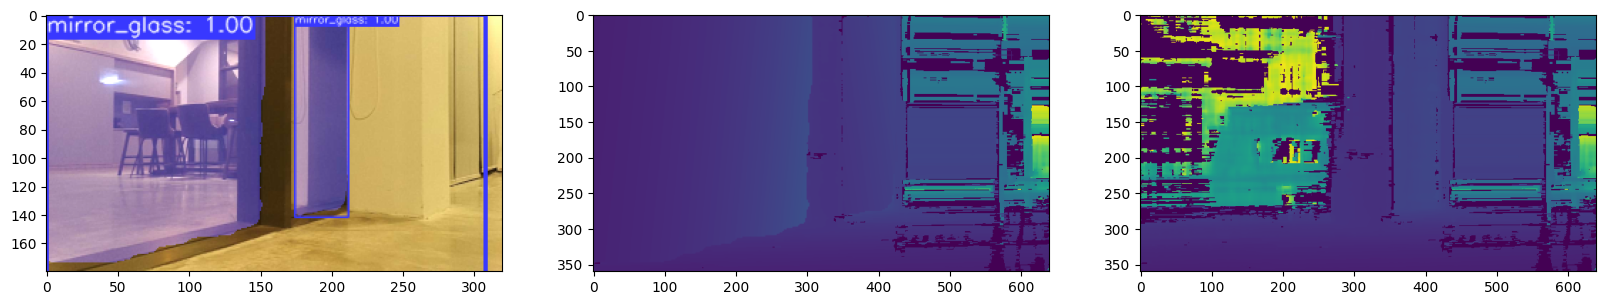

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[0].imshow(drawed_img[..., ::-1])
axes[1].imshow(ref_depth, cmap="viridis")
axes[2].imshow(ori_depth_1, cmap="viridis")
plt.show()